## Support Vector Classifier Implementation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Lets create synthetic data points
from sklearn.datasets import make_classification

In [3]:
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,
                        n_clusters_per_class=2,n_redundant=0)

In [4]:
X

array([[-0.64259528, -0.32539159],
       [-1.52158784,  1.72634829],
       [-1.44795865,  1.54236752],
       ...,
       [ 0.81085814, -1.18874413],
       [-1.74581907,  1.95973205],
       [-1.06062455,  1.01467047]], shape=(1000, 2))

In [5]:
y

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,

In [6]:
pd.DataFrame(X)[0]

0     -0.642595
1     -1.521588
2     -1.447959
3     -0.562082
4     -0.670144
         ...   
995    0.179064
996    2.019857
997    0.810858
998   -1.745819
999   -1.060625
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

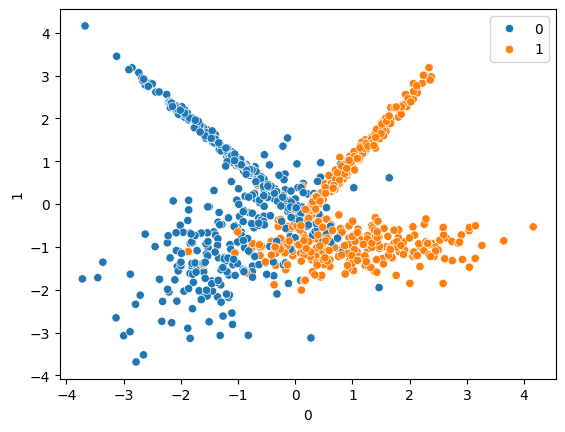

In [7]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1],hue=y)

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [9]:
from sklearn.svm import SVC

- Linear Kernel: It is used when data is linearly separable. RBF kernel is used when data is not linearly separable. It maps the data to higher dimension and then finds the hyperplane to separate the data.

In [10]:
svc=SVC(kernel='linear')

In [11]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [12]:
svc.coef_

array([[ 2.09333415, -0.67211291]])

In [13]:
# Prediction
y_pred=svc.predict(X_test)

In [14]:
from sklearn.metrics import classification_report,confusion_matrix

In [15]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91       133
           1       0.87      0.93      0.90       117

    accuracy                           0.90       250
   macro avg       0.90      0.91      0.90       250
weighted avg       0.91      0.90      0.90       250

[[117  16]
 [  8 109]]


- Radius Basis Function Kernel: RBF is used when data is not linearly separable. It uses a non-linear transformation to map the data into a higher-dimensional space where it can be separated by a hyperplane. The RBF kernel is defined as:

In [16]:
rbf=SVC(kernel='rbf')

In [17]:
rbf.fit(X_train,y_train)

SVC()

In [18]:
# Prediction
y_pred1=rbf.predict(X_test)

In [19]:
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       133
           1       0.88      0.95      0.91       117

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[118  15]
 [  6 111]]


- Polynomial Kernel: It is used when data is not linearly separable and we want to find a non-linear decision boundary. It maps the input features into a higher-dimensional space where a linear separation is possible. The polynomial kernel can capture complex relationships between features, making it suitable for datasets with non-linear patterns. The degree of the polynomial can be adjusted to control the flexibility of the decision boundary.

In [20]:
polynomial=SVC(kernel='poly')
polynomial.fit(X_train,y_train)

# Prediction
y_pred2=polynomial.predict(X_test)
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.83      0.94      0.88       133
           1       0.92      0.79      0.85       117

    accuracy                           0.87       250
   macro avg       0.88      0.86      0.87       250
weighted avg       0.87      0.87      0.87       250

[[125   8]
 [ 25  92]]


- Sigmoid Kernel: It is used in the case of neural networks. It is not used much in the case of SVM. It is used when we have a large number of features and we want to reduce the dimensionality of the data. It is also used when we have a large number of samples and we want to reduce the computational cost.

In [21]:
sigmoid=SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)

# Prediction
y_pred3=sigmoid.predict(X_test)
print(classification_report(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81       133
           1       0.78      0.77      0.78       117

    accuracy                           0.79       250
   macro avg       0.79      0.79      0.79       250
weighted avg       0.79      0.79      0.79       250

[[108  25]
 [ 27  90]]


In [22]:
sigmoid.intercept_

array([1.8566528])

___
___

## Hyperparameter Tuning with SVC

In [23]:
from sklearn.model_selection import GridSearchCV
 
# Defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

In [24]:
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,cv=5,verbose=3)

In [25]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.940 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.860 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.907 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.893 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [26]:
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [27]:
# Prediction
y_pred4=grid.predict(X_test)
print(classification_report(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       133
           1       0.90      0.92      0.91       117

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[121  12]
 [  9 108]]
